In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformer import Transformer
import math
import torch.nn.functional as F

We'll load the data from running the model.

In [2]:
data = np.load('logs.npz')
train_loss = data['train_loss']
test_loss = data['test_loss']
train_acc = data['train_acc']
test_acc = data['test_acc']

epochs = 40000
x_val = range(0, epochs, 100)

We'll show the plots for the first 20000 epochs; the last 20000 are not so interesting (they're relatively consistent with the preceding ~15000 epochs.)

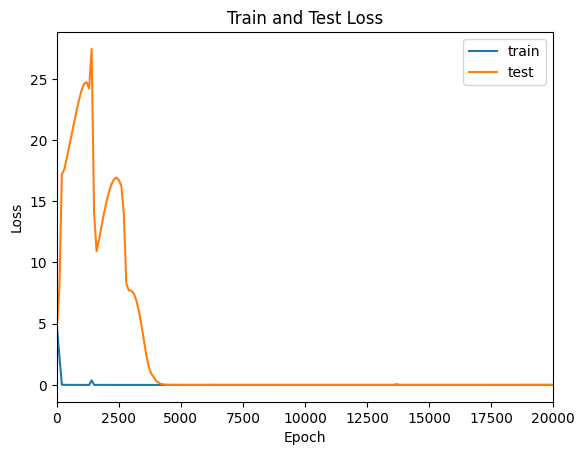

In [3]:
plt.plot(x_val, train_loss, label = 'train')
plt.plot(x_val, test_loss, label = 'test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Test Loss')
plt.xlim(0,20000)
plt.legend()
plt.savefig('figures/loss.png')
plt.show()

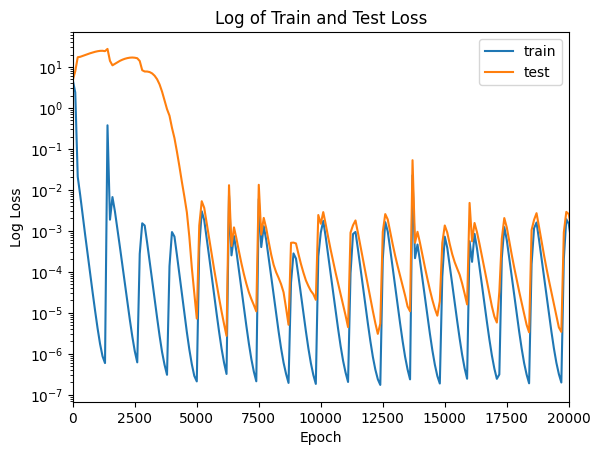

In [4]:
plt.plot(x_val, train_loss, label = 'train')
plt.plot(x_val, test_loss, label = 'test')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('Log of Train and Test Loss')
plt.yscale('log')
plt.xlim(0,20000)
plt.legend()
plt.savefig("figures/log_loss.png")
plt.show()

The train loss descends to ~0 very quickly, whereas the test loss remains high for a few thousand epochs, then also descends to ~0. The log-scale plot shows oscillations between lower and higher losses, but all still, on the absolute scale, quite low.

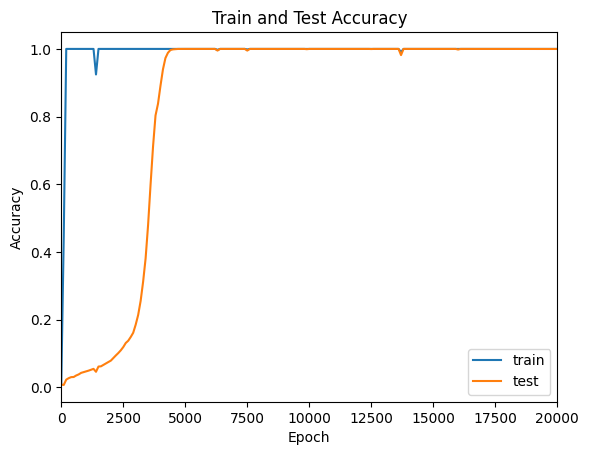

In [5]:
plt.plot(x_val, train_acc, label = 'train')
plt.plot(x_val, test_acc, label = 'test')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train and Test Accuracy')
plt.xlim(0,20000)
plt.legend()
plt.savefig("figures/acc.png")
plt.show()

Training accuracy ascends to ~1 almost immediately, and test accuracy remains relatively low for a few thousand epochs before rapidly ascending to ~1. Now we'll proceed to Fourier analysis of the weights.

In [6]:
# load model
model = Transformer()
model.load_state_dict(torch.load('model.pth'))

# load embedding and unembedding matrices
We = model.We.detach() # 114 diff chars; each row corresponds to an embedding in 128-dimensional space; 114 x 128
Wu = model.Wu.detach() # after processing the input, we get 128-dimensional vectors at position 2 ('='). need to project them into 114-dimensional space to predict. 128 x 114

We'll build the Fourier basis vectors.

They're of the following forms, though normalized:
* 56 vectors like the following: $\left( \sin \left( \frac{2k \pi \cdot 0}{113} \right) , \sin \left( \frac{2k \pi \cdot 1}{113} \right), \sin \left( \frac{2k \pi \cdot 2}{113} \right), \ldots , \sin \left( \frac{2k \pi \cdot 112}{113} \right) \right)$
* 56 vectors like the following: $\left( \cos \left( \frac{2k \pi \cdot 0}{113} \right) , \cos \left( \frac{2k \pi \cdot 1}{113} \right), \cos \left( \frac{2k \pi \cdot 2}{113} \right), \ldots , \cos \left( \frac{2k \pi \cdot 112}{113} \right) \right)$
* An all-ones vector: $(1, 1, \ldots , 1)$.

This basis is orthogonal. We'll just show that two vectors of the first form are orthogonal. Suppose $f_a$, $f_b$ are Fourier basis vectors of the first form with $k = a$ and with $k = b$, and $a \neq b$.

We have
\begin{align*}
\sin \left( \frac{2m \pi a}{113} \right) \sin \left(  \frac{2m\pi b}{113}\right) = \frac{1}{2} \left[ \cos \left(\frac{2(a-b)m\pi}{113} \right) - \cos \left( \frac{2(a+b)m\pi}{113}\right) \right]
\end{align*}
by the product-to-sum rule. So 
\begin{align*}
f_a \cdot f_b = \frac{1}{2}\sum_{m=0}^{112} \left[ \cos \left(\frac{2(a-b)m\pi}{113} \right) - \cos \left( \frac{2(a+b)m\pi}{113}\right) \right].
\end{align*}
But as $1 \le a \neq b \le 56$, we know that $a -b \neq 0$ and $a + b \neq 0$. Therefore as $113$ is prime, both $2m(a-b)$ and $2m(a + b)$ achieve every possible residue modulo $113$. From here we can easily obtain $\sum_{m=0}^{112}\cos \left(\frac{2(a-b)m\pi}{113} \right) = \sum_{m=0}^{112}\cos \left(\frac{2(a+b)m\pi}{113} \right)$, though there's actually a stronger result; note that each sum is the sum of the real parts of the $113$ roots of unity, which themselves sum to $0$, and the real part of $0$ is $0$.

(The rest of the cases are similar and we'll ignore them.)

In [7]:
N = 113
M = int((N+1)/2)

fourier_basis = []
for k in range(1,M):
    # each sin basis vector looks as follows: [sin((2kpi*0)/113), sin((2kpi*1)/113), ..., sin((2kpi*112)/113)]
    fourier_basis.append([math.sin(2 * k * math.pi * x / N) for x in range(N)])

for k in range(1,M):
    # each cos basis vector looks as follows: [cos((2kpi*0)/113), cos((2kpi*1)/113), ..., cos((2kpi*112)/113)]
    fourier_basis.append([math.cos(2 * k * math.pi * x / N) for x in range(N)])

# add the all-ones vector
fourier_basis.append([1] * N)
fourier_basis = torch.tensor(fourier_basis)

# normalize
fourier_basis = F.normalize(fourier_basis, dim = 1)


Next, we'll project the embedding matrix onto the Fourier basis. 

A bit of math first. Call our weight embedding matrix $W_e$; we'll use the first 113 rows (every row except the row corresponding to the '='.) Represent it as $[w_1, w_2, \ldots , w_{128}]$, where the $w_i$'s are $113$-dimensional column vectors. They can be thought of as containing the $i$-th dimension coordinate for each embedding of each character.

Call our Fourier basis matrix $F$; represent it as $\begin{bmatrix}  b_1 \\ b_2 \\ \vdots \\ b_{113} \end{bmatrix}$. Here the basis vectors are $113$-dimensional and orthonormal (that is, they have norm $1$ and are all orthogonal to each other.)

The coefficient matrix is 
$$P = FW_e = \begin{bmatrix}
b_1 \cdot w_1 & b_1 \cdot w_2 & \cdots & b_1 \cdot w_{128} \\
b_2 \cdot w_1 & b_2 \cdot w_2 & \cdots & b_2 \cdot w_{128} \\
\vdots & \vdots & \ddots & \vdots \\
b_{113} \cdot w_1 & b_{113} \cdot w_2 & \cdots & b_{113} \cdot w_{128}
\end{bmatrix}.$$

We will note that this matrix $P$ has the property that $P^T F = W_e^T$. That is, we'll claim that
\begin{align*}
\begin{bmatrix}
b_1 \cdot w_1 & b_2 \cdot w_1 & \cdots & b_{113} \cdot w_1 \\
b_1 \cdot w_2 & b_2 \cdot w_2 & \cdots & b_{113} \cdot w_2 \\
\vdots & \vdots & \ddots & \vdots \\
b_1 \cdot w_{128} & b_2 \cdot w_{128} & \cdots & b_{113} \cdot w_{128}
\end{bmatrix} \begin{bmatrix}  b_1 \\ b_2 \\ \vdots \\ b_{113} \end{bmatrix} = \begin{bmatrix} w_1 \\ w_2 \\ \vdots \\ w_{128} \end{bmatrix}.
\end{align*}
Consider the $j$-th row of this multiplication. We'd like 
$$(b_1 \cdot w_j) b_1 + \ldots + (b_{113} \cdot w_j) b_{113} = w_j.$$

As $\{b_1, \ldots , b_{113}\}$ comprises a basis for $\mathbb{R}^{113}$, we know that
$$w_j = c_1 b_1 + \ldots + c_{113} b_{113}$$
for some constants $c_1, \ldots , c_{113}$. Dot both sides by $b_k$. We obtain
\begin{align*}w_j \cdot b_k & = c_1 (b_1 \cdot b_k) + \ldots + c_{113} (b_{113} \cdot b_k) \\
& = c_k (b_k \cdot b_k) \\ &= c_k
\end{align*}
where we've used that the basis is orthonormal to conclude $b_i \cdot b_k = 0$ when $i \neq k$ and $b_k \cdot b_k = 1$. Then we substitute this back in to get
\begin{align*}
w_j &= c_1 b_1 + \ldots + c_{113} b_{113} \\
&= (w_j \cdot b_1) b_1 + \ldots + (w_j \cdot b_{113}) b_{113}\end{align*}
as desired.

In [8]:
# get the first 113 rows; the 114th corresponds to the equals sign
We_num = We[:113,:]
projections_e = fourier_basis @ We_num # 113 x 128

Next we want the norms for each row of the coefficient matrix.

The first row of the coefficient matrix is $[b_1\cdot w_1, b_1 \cdot w_2, \ldots , b_1 \cdot w_{128}]$. Note that the entry $b_1 \cdot w_j$ can be thought of as the contribution from $b_1$ to $w_j$ in the decomposition of $w_j$ into a linear combination of basis vectors $b_1, \ldots , b_{113}$. Thus the norm $\sqrt{(b_1 \cdot w_1)^2 + \ldots + (b_1 \cdot w_{128})^2}$ can be thought of as the total contribution from $b_1$ toward the weight matrix. 

More generally speaking then, the $i$-th row of the norms matrix will represent the total contribution from $b_i$ toward the embedding matrix. We will identify the basis vectors that have the largest contributions toward the embedding matrix.

In [9]:
norms_e = torch.linalg.vector_norm(projections_e, dim = 1)
torch.topk(norms_e, k = 10)

torch.return_types.topk(
values=tensor([5.9188, 5.5826, 5.5478, 5.2969, 5.1249, 5.0590, 4.6011, 4.5009, 2.0585,
        1.8899]),
indices=tensor([ 48,  68, 104,  38,  94,  12,  74,  18,  34,  90]))

Basis vectors $b_i$ with $i = 48, 68, 104, 38, 94, 12, 74, 18, 34, 90$ (for the basis matrix in the code) contribute much more toward the embedding matrix than the rest of the basis vectors.

Note that these correspond to normalized versions of the following basis vectors, mathematically speaking: $\left[\sin( \frac{2k \pi \cdot 0}{113}), \sin( \frac{2k \pi \cdot 1}{113}), ..., \sin( \frac{2k \pi \cdot 112}{113})\right]$ for $k = 13, 19, 35, 39, 49$, and $\left[\cos( \frac{2k \pi \cdot 0}{113}), \cos( \frac{2k \pi \cdot 1}{113}), ..., \cos( \frac{2k \pi \cdot 112}{113})\right]$ for $k = 13, 19, 35, 39, 49$ too; recall that the $\sin$ vectors correspond to rows $1-56$, the $\cos$ vectors correspond to rows $57-112$, and the all-ones vector is row $113$.

Next, we'll analyze $W_L$, which in the paper is the matrix that is one component of the mapping of MLP activations to logits, $W_2 W_U$.

In [10]:
W2 = model.mlp.W2.detach()
Wu = model.Wu.detach()
WL = W2 @ Wu 
WL_num = WL[:,:113].T

In [11]:
projections_L = fourier_basis @ WL_num # 113 x 512
norms_L = torch.linalg.vector_norm(projections_L, dim = 1)
torch.topk(norms_L, k = 10)

torch.return_types.topk(
values=tensor([12.9304,  8.9835,  8.6406,  8.2650,  8.0828,  7.8944,  6.9489,  6.7799,
         5.5313,  1.7409]),
indices=tensor([112,  94, 104,  38,  12,  68,  48,  74,  18,  14]))

Note that these correspond to $k = 13, 15, 19, 39, 49$ for the $\sin$ vectors, $k = 13, 19, 39, 49$ for the $\cos$ vectors, and the all-ones vector.

Now we'll reverse-engineer the algorithm. First, we'll get the MLP pre-activations for all $113^2$ input pairs.

In [12]:
params = {}
for name, param in model.named_parameters():
    print(name, param.shape)
    params[name] = param.detach()

d_embd=128
num_heads=4
d_head=32
n_hunit=512
num_chars=114
mask = torch.triu(torch.ones(3,3) * (-1e10), diagonal=1)


We torch.Size([114, 128])
Wpos torch.Size([3, 128])
Wq torch.Size([4, 32, 128])
Wk torch.Size([4, 32, 128])
Wv torch.Size([4, 32, 128])
Wo torch.Size([128, 128])
Wu torch.Size([128, 114])
mlp.W1 torch.Size([128, 512])
mlp.b1 torch.Size([512])
mlp.W2 torch.Size([512, 128])
mlp.b2 torch.Size([128])


In [13]:
# to store the data
all_data = np.zeros((N**2, 4), dtype = int)

# generate 113^2 pairs 
for i in range(N):
    for j in range(N):
        # i + j = (i + j) mod N
        # we code = as N itself
        all_data[i*N + j] = [i,j,N, (i+j) % N]

# get inputs and outputs
all_data = torch.tensor(all_data)
all_Ys = all_data[:,3]
all_data = all_data[:,:3]

In [ ]:
with torch.no_grad():
    # next, we'll manually run through the algorithm
    X_embd = params['We'][all_data] + params['Wpos'] # 12769x3x128

    # QKV projection: 12769x3x32x4
    Q = torch.einsum('abc, dec->abed', X_embd, params['Wq'])
    K = torch.einsum('abc, dec->abed', X_embd, params['Wk'])
    V = torch.einsum('abc, dec->abed', X_embd, params['Wv'])

    # attention matrix: 12769x3x3x4
    attn = F.softmax(torch.einsum('abcd, aecd->abed', Q, K)/(d_head**0.5) + mask[:,:,None], dim = 2)

    # multiply by V: 12769x3x32x4
    attn_head_out = torch.einsum('abcd, aced->abed', attn, V)

    # concatenate: 12769x3x128
    multi_head_out = torch.cat([attn_head_out[:,:,:,_] for _ in range(num_heads)], dim = 2)

    # transform with attention out matrix: 12769x3x128
    attn_layer_out = torch.einsum('abc, cd->abd', multi_head_out, params['Wo'])

    # residual connection: 12769x3x128
    X_embd = X_embd + attn_layer_out

    # first MLP layer: 12769x3x512
    preact = torch.einsum('abc,cd->abd', X_embd, params['mlp.W1']) + params['mlp.b1']

We'll look at the attention weights to confirm that the attention heads at position 2 attend to positions 0 and 1, but not really to position 2. In all the cases below, we're averaging across the attention at position 2 for each possible computation, and we're getting that position 2 pays basically no attention to itself and pays roughly equal attention to positions 0 and 1.

In [50]:
print(torch.mean(attn[:, 2, :, 0], dim = 0))
print(torch.mean(attn[:, 2, :, 1], dim = 0))
print(torch.mean(attn[:, 2, :, 2], dim = 0))
print(torch.mean(attn[:, 2, :, 3], dim = 0))

tensor([0.4972, 0.4957, 0.0072])
tensor([0.4949, 0.4936, 0.0116])
tensor([0.4955, 0.5005, 0.0040])
tensor([0.4996, 0.4921, 0.0083])


We need the pre-activations at specifically position 2, because position 2 can see the previous positions (due to the causal mask.) Next, we'll plot the pre-activations for input $(a,b,'=')$ with $a = 0$ fixed as a function of $b$. We'll also do a sanity check with $a = 50$, too.

In [58]:
# with a = 0, we just need the first 113 elements of preact
pos2_preacts_0 = preact[:113,2,:]

# with a = 20, we need 20*113 through 21*113
pos2_preacts_50 = preact[50*113:51*113, 2, :]

We'll plot the first few neurons.

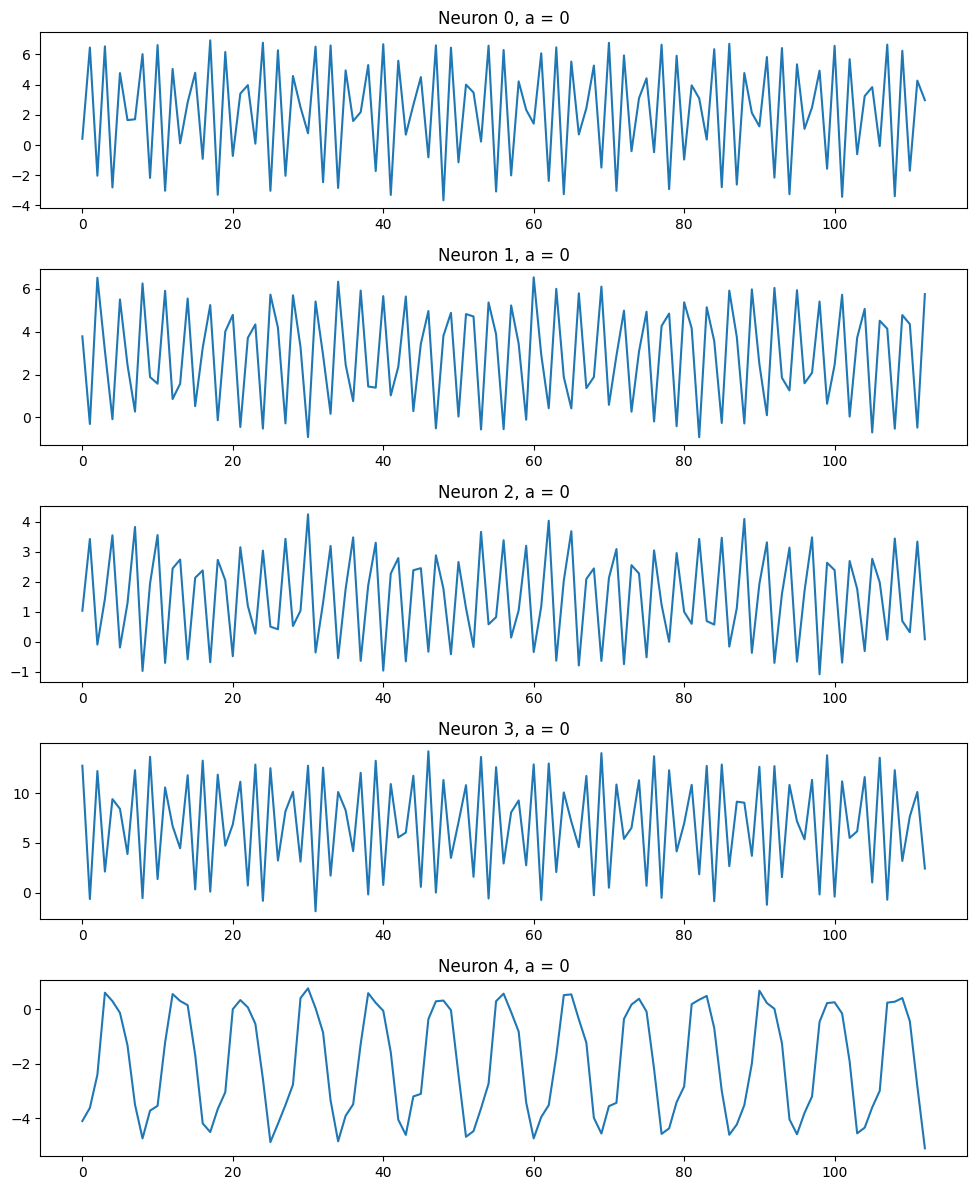

In [53]:
fig, axes = plt.subplots(5,1, figsize=(10,12))
for i in range(5):
    # plot the ith neuron's preactivations
    # there are 512 total; we'll plot 5 of them
    axes[i].plot(range(113), pos2_preacts_0[:, i])
    axes[i].set_title(f'Neuron {i}, a = 0')

plt.tight_layout()
plt.show()

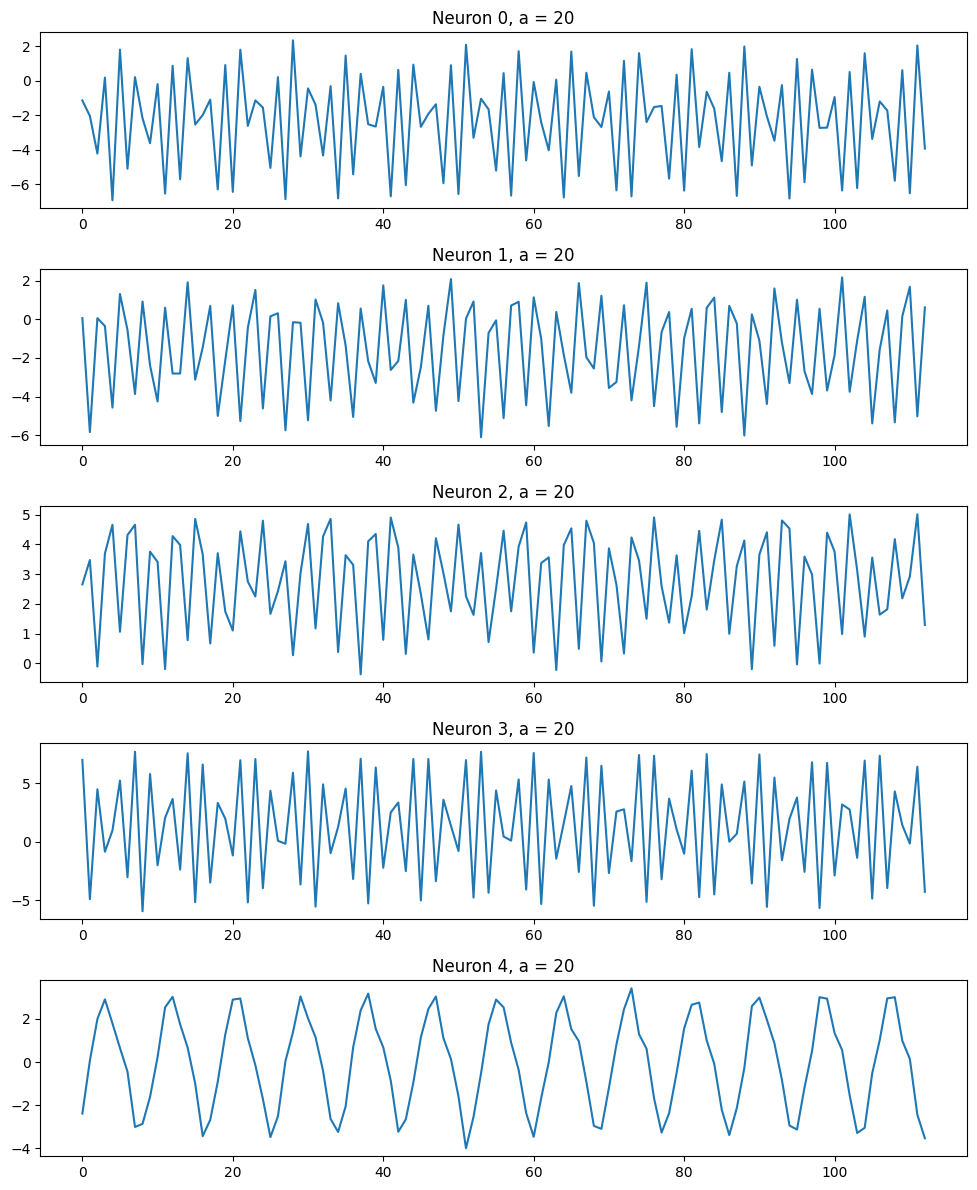

In [ ]:
fig, axes = plt.subplots(5,1, figsize=(10,12))
for i in range(5):
    # plot the ith neuron's preactivations
    # there are 512 total; we'll plot 5 of them
    axes[i].plot(range(113), pos2_preacts_50[:, i])
    axes[i].set_title(f'Neuron {i}, a = 50')

plt.tight_layout()
plt.show()

One can observe that the neuron pre-activations are sinusoidal waves. They also clearly have differing frequencies. We'll now Fourier analyze these pre-activation curves. We'll do so by projecting the curves onto the Fourier basis constructed earlier. Recall that the basis vectors with the largest contribution toward the embedding matrix were those with $k = 13, 19, 35, 39,$ or $49$.

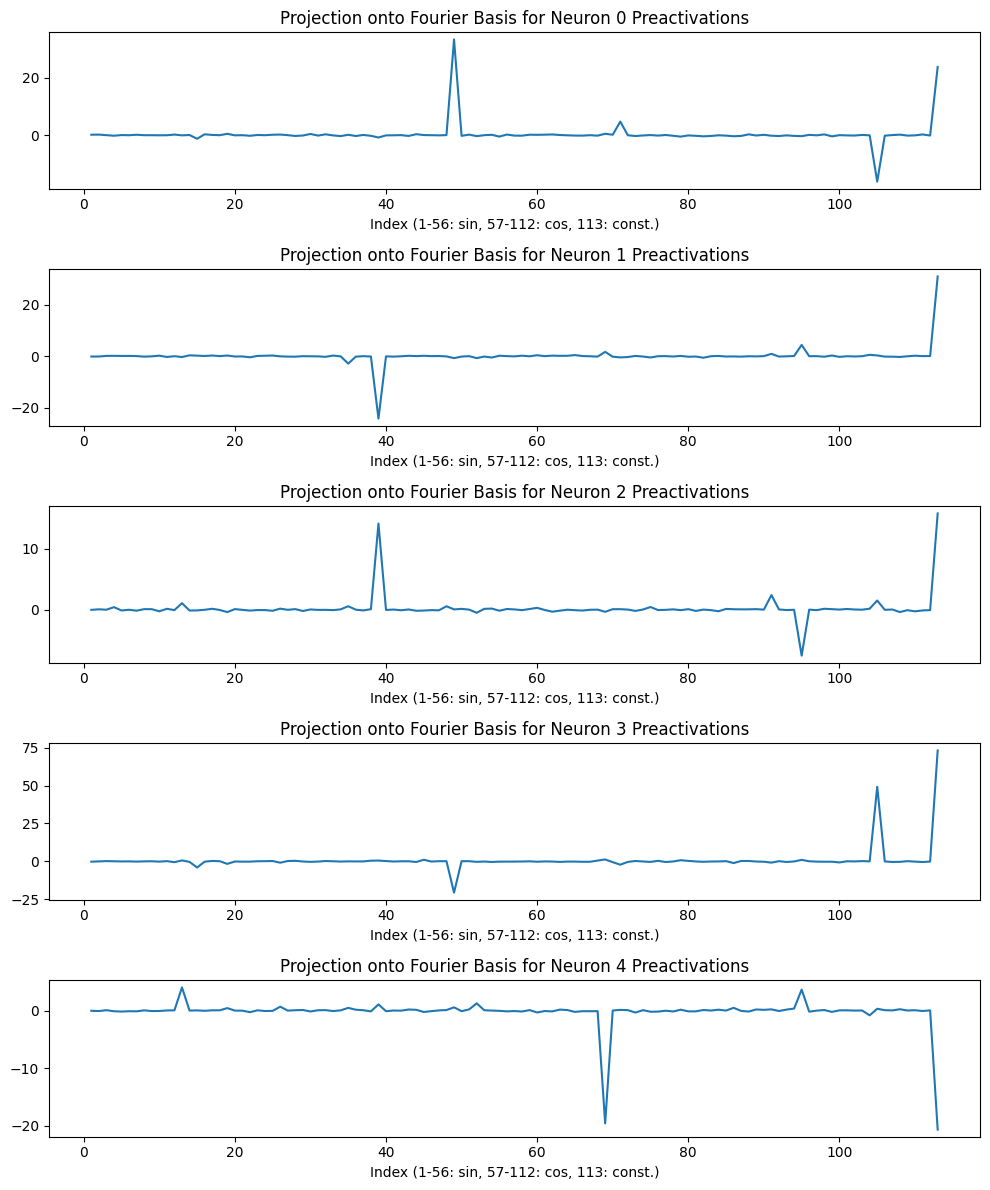

In [ ]:
fig, axes = plt.subplots(5,1, figsize=(10,12))
for i in range(5):
    # plot the ith neuron's preactivations
    # there are 512 total; we'll plot 5 of them
    # plot starts from 1 due to zero-indexing in Python vs. 1-indexing for basis vectors

    axes[i].plot(range(1,114), fourier_basis @ pos2_preacts_0[:, i])
    axes[i].set_title(f'Projection onto Fourier Basis for Neuron {i} Preactivations')
    axes[i].set_xlabel('Index (1-56: sin, 57-112: cos, 113: const.)')

plt.tight_layout()
plt.show()

We'll also plot the energy per frequency $k$. The energy, in this case, is just the sum of the squared coefficients for $\left[\sin( \frac{2k \pi \cdot 0}{113}), \sin( \frac{2k \pi \cdot 1}{113}), ..., \sin( \frac{2k \pi \cdot 112}{113})\right]$ and $\left[\cos( \frac{2k \pi \cdot 0}{113}), \cos( \frac{2k \pi \cdot 1}{113}), ..., \cos( \frac{2k \pi \cdot 112}{113})\right]$, the basis vectors corresponding to frequency $k$.

Neuron 0 frequency: 49
Neuron 1 frequency: 39
Neuron 2 frequency: 39
Neuron 3 frequency: 49
Neuron 4 frequency: 13


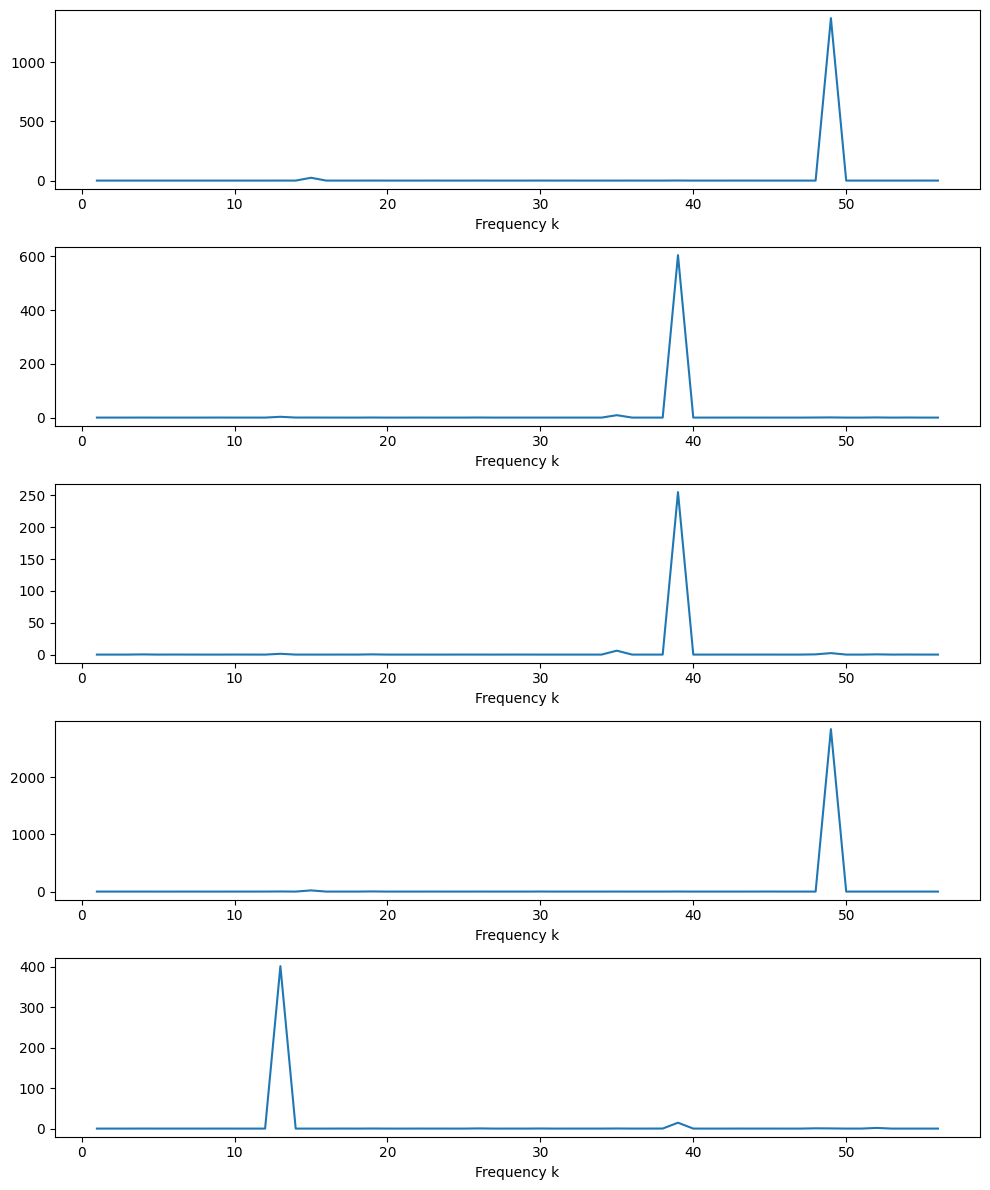

In [18]:
fig, axes = plt.subplots(5,1, figsize=(10,12))
for i in range(5):
    
    coeffs = fourier_basis @ pos2_preacts_0[:,i]
    energy = torch.zeros(56)
    for k in range(56):
        # cos and sin are off by 56
        energy[k] = coeffs[k]**2 + coeffs[56+k]**2

    # plot starts from 1 due to zero-indexing in Python vs. 1-indexing for basis vectors
    axes[i].plot(range(1,57), energy)
    axes[i].set_xlabel('Frequency k')

    # add 1 again due to 1-indexing for basis vectors vs zero-indexing in python
    print(f'Neuron {i} frequency: {torch.argmax(energy).item()+1}')

plt.tight_layout()
plt.show()

Now we'll compute the number of neurons tuned to each frequency.

In [ ]:
all_coeffs = fourier_basis @ pos2_preacts_0

# split into sin and cos to calculate energies
sin_coeffs = all_coeffs[:56] # 56 x 512
cos_coeffs = all_coeffs[56:112] # 56 x 512
energies = sin_coeffs**2 + cos_coeffs**2 # 56 x 512

# frequency is the argmax. adding 1 due to k vs Python indexing mismatch
freqs = torch.argmax(energies, dim = 0) + 1

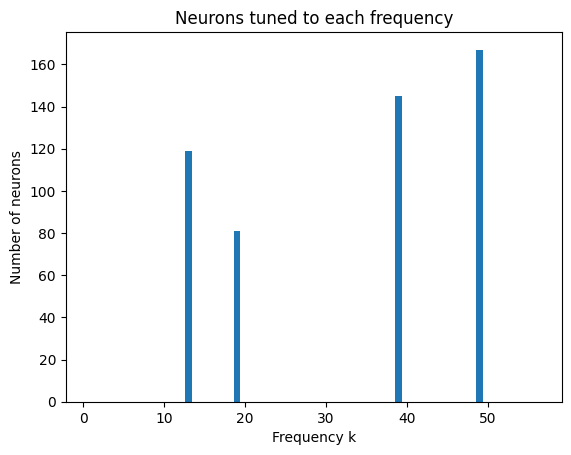

In [20]:
counts = torch.bincount(freqs, minlength=57)  # counts[k] = # neurons at frequency k
plt.bar(range(1, 57), counts[1:57]) # 56 total frequencies
plt.xlabel('Frequency k')
plt.ylabel('Number of neurons')
plt.title('Neurons tuned to each frequency')
plt.savefig('figures/neurons_tuning.png')
plt.show()

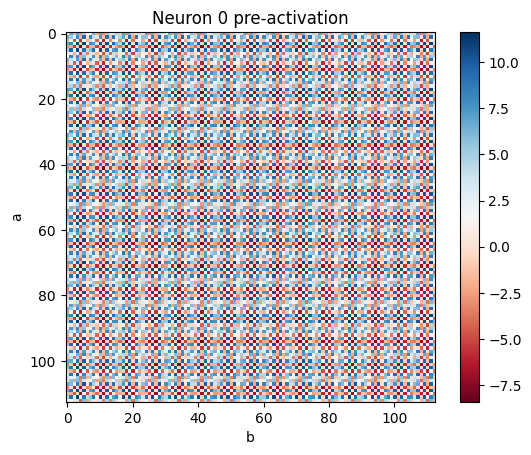

In [21]:
neuron_idx = 0

# preact[:,2,neuron_idx] does the following:
# over all 113^2 input pairs, at position 2 ('=') sign, it gives the preactivation for neuron neuron_idx.
heatmap = preact[:, 2, neuron_idx].reshape(113, 113)
# reshaping to 113x113 due to the way we generated the 113^2 pairs
# if a b = c, then we had 0 0 = 0, 0 1 = 1, ... , 0 112 = 112, 1 0 = 1, etc.
plt.imshow(heatmap, cmap='RdBu', aspect='equal')
plt.xlabel('b')
plt.ylabel('a')
plt.colorbar()
plt.title(f'Neuron {neuron_idx} pre-activation')
plt.show()

The preactivations look checkerboard-esque. This makes sense: both horizontally and vertically preactivations are like a sin wave, so the blue areas are where their peaks overlap, and the red areas are where their valleys overlap.

Next we'll restrict to key frequencies. We'll zero out non-key-frequency components in the logits and check model performance. We previously already got all the preactivations, so it's not hard to continue the algorithm to get the logits.

In [63]:
with torch.no_grad():
    # relu
    h = F.relu(preact)

    # mlp second layer
    mlp_out = torch.einsum('abc, cd->abd', h, params['mlp.W2']) + params['mlp.b2']

    # residual connection
    X_embd = X_embd + mlp_out
    
    # logits. need only third column ('=' character). 
    logits = torch.einsum('abc, cd->abd', X_embd, params['Wu'])[:,2,:113]


Once again, the Fourier basis can be expressed as 
$$F = \begin{bmatrix}
b_1 \\ \vdots \\ b_{113} \end{bmatrix}$$
for basis row vectors $b_1$ through $b_{113}$. Now the matrix of logits $L$ has dimension $113^2 \times 113$. So therefore
$$L^T = \begin{bmatrix}
\text{logit}_{0,0} & \text{logit}_{0,1} & \cdots & \text{logit}_{112,112} \end{bmatrix}$$
where $\text{logit}_{i,j}$ is the $113$-dimensional column vector of logits assigned to each possible output of $0, 1, \ldots , 112$.

The coefficient matrix is
$$P_L = FL^T.$$

We know also that $F^TF = I$ as $F$ is orthonormal, so
$$F^T P_L = L^T,$$
or equivalently,
$$
\begin{bmatrix}
b_1^T & \cdots & b_{113}^T
\end{bmatrix}
\begin{bmatrix}
b_1 \cdot \text{logit}_{0,0} & \cdots & b_{1} \cdot \text{logit}_{112,112} \\
\vdots & \ddots & \vdots \\
b_{113} \cdot \text{logit}_{0,0} & \cdots & b_{113} \cdot \text{logit}_{112,112} \end{bmatrix}
= \begin{bmatrix}
\text{logit}_{0,0} & \text{logit}_{0,1} & \cdots & \text{logit}_{112,112} \end{bmatrix}.
$$

This is just a more direct way of showing that $P_L$ is the matrix whose entries are coefficients for the Fourier basis. Now we'll zero out the entries of $P_L$ that don't correspond to $k = 13, 19, 35, 39, 49$, or the all-ones vector.

In [23]:
projections_L = fourier_basis @ logits.T
high_contribs = torch.tensor([13, 19, 35, 39, 49])
to_zero = high_contribs - 1
to_zero = torch.concatenate([to_zero, to_zero + 56], dim = 0)

In [24]:
neg_proj_L = -projections_L
for row in to_zero:
    neg_proj_L[row] = torch.zeros(113**2)

last_row = projections_L[112]
neg_proj_L[112] = torch.zeros(113**2)

# key_freqs is a matrix containing only frequencies corresponding to k = 13, 19, 35, 39, 49, (and the all-ones vector)
# notkey_freqs is a matrix containing all the other frequencies (and the all-ones vector)
key_freqs = projections_L + neg_proj_L
notkey_freqs = projections_L - key_freqs
notkey_freqs[112] = last_row

Now we'll project back into the original space by multiplying by $F^T$. We'll calculate loss.

In [25]:
key_freqs_logits = fourier_basis.T @ key_freqs # 113 x 12769
notkey_freqs_logits = fourier_basis.T @ notkey_freqs # 113 x 12769
key_loss = F.cross_entropy(key_freqs_logits.T, all_Ys)
notkey_loss = F.cross_entropy(notkey_freqs_logits.T, all_Ys)

In [26]:
print(key_loss)
print(notkey_loss)

tensor(1.1317)
tensor(17.8744)


The loss when we zero out the key frequencies is very large, and the loss when we zero out the non-key-frequencies is quite small, as expected. 

Now we'll look at progress measures. We'll compute the test loss based on key frequencies and non-key-frequencies throughout training. We retroactively know the key frequencies for this random seed, so we'll just stick with that. That will happen in train_checkpoints.py.

In [27]:
checkpoints_data = np.load('checkpoints/logs_progress.npz')

In [28]:
restricted_loss = checkpoints_data['restricted_loss']
excluded_loss = checkpoints_data['excluded_loss']
x_val_checkpoints = range(0, 10000, 100)

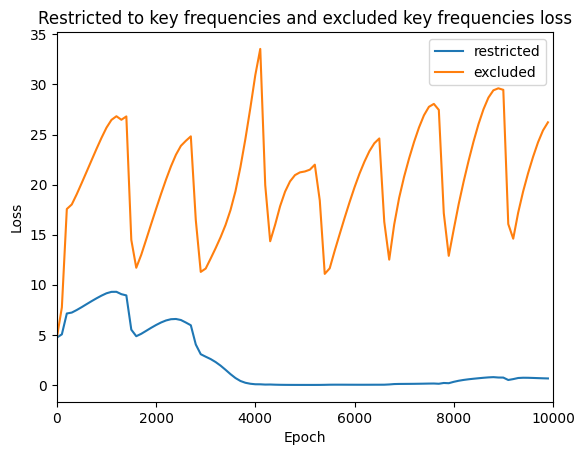

In [29]:
plt.plot(x_val_checkpoints, restricted_loss, label = 'restricted')
plt.plot(x_val_checkpoints, excluded_loss, label = 'excluded')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Restricted to key frequencies and excluded key frequencies loss')
plt.xlim(0,10000)
plt.legend()
plt.savefig('figures/checkpoints_loss.png')
plt.show()

Note that the restricted loss begins to drop sooner than the test accuracy begins to improve. This is shown more clearly in the paper, probably due to a different starting seed.

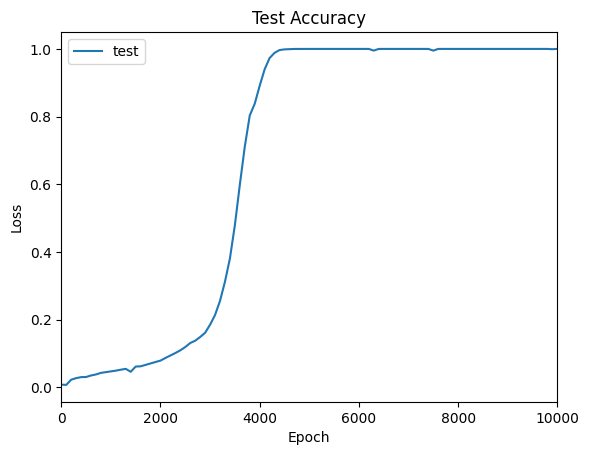

In [97]:
plt.plot(x_val, test_acc, label = 'test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Test Accuracy')
plt.xlim(0,10000)
plt.legend()
plt.show()

Now we'll work toward reconstructing the algorithm.

In [ ]:
k = 13
neuron_mask = (freqs == k)

# h is 12769x3x512
# h_13 is 12769x512 without the mask, with just the position 2 post-ReLU activations
# also get just the neurons tuned to k
h_13 = h[:, 2, :][:, neuron_mask]  # 12769x|S_k|

# get the logit contributions from the neurons tuned to frequency 13
logit_contrib_13 = h_13 @ W2[neuron_mask, :] @ Wu[:, :113]  # (12769, 113)
# We use Wu[:, :113] because again we don't care about the '='

Here, logit_contrib_13 is a 12769 by 113 matrix, such that the entry at row $i$ and column $j$ gives the contribution of the neurons tuned to frequency $13$ toward the answer $j$ for the $i$th sum. The sums are $0 + 0, 0 + 1, 0 + 2, \ldots , 1 + 0, 1 + 1, \ldots , 112 + 112$. So for example, the entry at row $2$ and column $1$ gives the contribution of the neurons tuned to the frequency $13$ toward the answer $1$ for the sum $0 + 2$.

We'll take the first column of logit_contrib_13, which gives the contribution of the neurons tuned to frequency $13$ toward the answer $0$ for each sum, and we'll construct a heatmap.

In [ ]:
heatmap = logit_contrib_13[:, 0].reshape(113, 113)

# average along each (a+b) mod 113 diagonal
a_idx = torch.arange(113).unsqueeze(1) # 113x1
b_idx = torch.arange(113).unsqueeze(0) # 1x113
sums = (a_idx + b_idx) % 113 # gives us a 113x113 matrix that looks like
# 0 1 2 ... 111 112
# 1 2 3 ... 112 0
# 2 3 4 ... 0   1 etc.

diagonal_avg = torch.zeros(113)
for s in range(113):
    # get the average contribution of the neurons tuned to 13 toward a + b = s for all possible a, b
    # for example, diagonal_avg[3] is the average contribution of the neurons tuned to 13 for (a,b) = (0,3),(1,2),(2,1),(3,0),(4,112),(5,111), etc.
    diagonal_avg[s] = heatmap[sums == s].mean()

In [ ]:
# get the coefficients for the fourier basis for the 113-dimensional diagonal vector
# that is, diagonal_avg = coeffs[0]*fourier_basis[0] + coeffs[1]*fourier_basis[1] + ... + coeffs[112]*fourier_basis[112]
coeffs = fourier_basis @ diagonal_avg
energy = torch.zeros(56)
for j in range(56):
    energy[j] = coeffs[j]**2 + coeffs[56 + j]**2 # essentially checks which frequency contributes the most; each freq has two basis vectors
print(f'Peak frequency: {torch.argmax(energy).item() + 1}')

Peak frequency: 13


So the frequency-13 group's contribution is a function of $a + b$, not individually $a$ or $b$.